# Evaluating differences in ASC

Notebook to do a first check in differences in ASC speed between runs

In [1]:
import intake
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import cf_xarray as cf
import xarray as xr
import cmocean.cm as cmocean
import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable
import shutil as shutil
from dask.distributed import Client


import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)
import warnings

In [2]:
client = Client(threads_per_worker = 1)
catalog = intake.cat.access_nri

In [3]:
Month_inds = slice(8,10)
start_date = '2000-01'
end_date = '2000-12'
time_slice=slice(start_date,end_date)
lat_slice=slice(-85,-59)

In [4]:
#in this definition, no frequency can be used only for static data
def importer(experiment,catalog,variable, frequency = 'fx',start_time=0,end_time=0):
    warnings.filterwarnings('ignore')
    var = catalog[experiment].search(variable=variable, frequency = frequency).to_dask(xarray_open_kwargs={'decode_timedelta':True})
    if start_time!=0:
        time_slice='slice(start_time,end_time)'
        return eval("var." + variable + ".sel(time=" + time_slice + ")")
    elif start_time ==0:
        return eval("var." + variable)

In [5]:
#importing uo's
panan01_U = importer("panant-01-zstar-ACCESSyr2",catalog,"uo",frequency = '1mon',start_time=start_date,end_time=end_date)
panan005_U = importer("panant-005-zstar-ACCESSyr2",catalog,"uo",frequency = '1mon',start_time=start_date,end_time=end_date)
panan0025_U = importer("panant-0025-zstar-ACCESSyr2",catalog,"uo",frequency = '1mon',start_time=start_date,end_time=end_date)

#importing vo's
panan01_V = importer("panant-01-zstar-ACCESSyr2",catalog,"vo",frequency = '1mon',start_time=start_date,end_time=end_date)
panan005_V = importer("panant-005-zstar-ACCESSyr2",catalog,"vo",frequency = '1mon',start_time=start_date,end_time=end_date)
panan0025_V = importer("panant-0025-zstar-ACCESSyr2",catalog,"vo",frequency = '1mon',start_time=start_date,end_time=end_date)

# extracting surface velocities
panan01_U0 = panan01_U.isel(z_l=0); panan01_V0 = panan01_V.isel(z_l=0);
panan005_U0 = panan005_U.isel(z_l=0); panan005_V0 = panan005_V.isel(z_l=0);
panan0025_U0 = panan0025_U.isel(z_l=0); panan0025_V0 = panan0025_V.isel(z_l=0);

lets now interpolate the surface velocities into the same grid xq yq of panan0025, to calcualte speed and ifferences between runs

In [6]:
#getting coords to interpolate
xqtarget = panan0025_U0.xq
yqtarget = panan0025_V0.yq

#interpolating coords, U0:
panan0025_U0q = panan0025_U0.mean('time').interp(yh=yqtarget).compute() #x already in the right grid
panan005_U0q = panan005_U0.mean('time').interp(xq=xqtarget,yh=yqtarget).compute()
panan01_U0q = panan01_U0.mean('time').interp(xq=xqtarget,yh=yqtarget).compute()

In [7]:
#interpolating coords, V0:
panan0025_V0q = panan0025_V0.mean('time').interp(xh=xqtarget).compute() #y already in the correct grid
panan005_V0q = panan005_V0.mean('time').interp(xh=xqtarget,yq=yqtarget).compute()
panan01_V0q = panan01_V0.mean('time').interp(xh=xqtarget,yq=yqtarget).compute()



In [10]:
#calcualting speed
panan01_speed0 = (panan01_U0q**2 + panan01_V0q**2)**0.5
panan005_speed0 = (panan005_U0q**2 + panan005_V0q**2)**0.5
panan0025_speed0 = (panan0025_U0q**2 + panan0025_V0q**2)**0.5

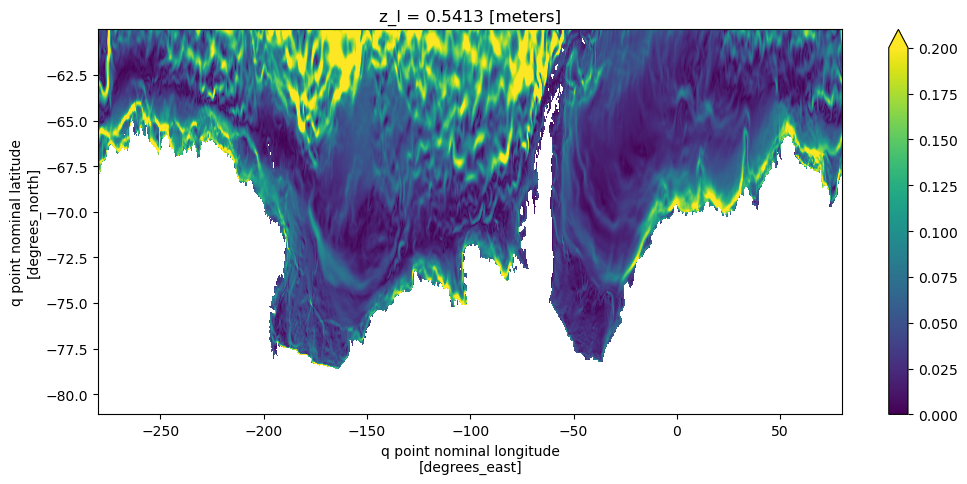

In [15]:
plt.figure(figsize=(12,5))
panan01_speed0.cf.sel({'latitude':slice(-82,-60)}).plot(vmin=0,vmax=0.2)

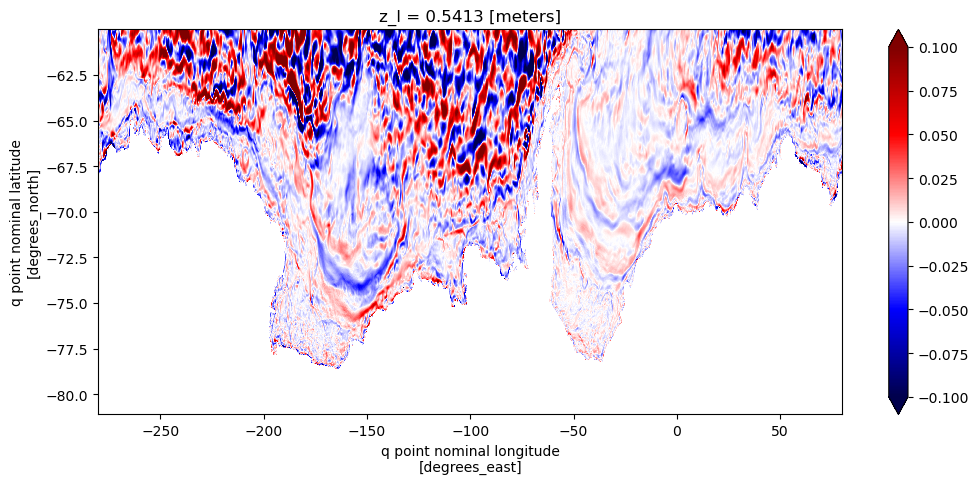

In [16]:
plt.figure(figsize=(12,5))
(panan005_speed0 - panan01_speed0).cf.sel({'latitude':slice(-82,-60)}).plot(cmap='seismic',vmin=-0.1,vmax=0.1)